# E-commerce Product Range Analysis
**Irene Undiandeye**

## Introduction

This project analyses about one year of transactions from an online store that sells household goods and gifts, with the aim of understanding which products drive the business, how sales change through the year, who the customers are, and what the store should do with its product range. The data covers 29 November 2018 to 7 December 2019 and contains the following columns: `InvoiceNo` (order identifier; cancellations start with "C"), `StockCode` (item identifier), `Description` (item name), `Quantity`, `InvoiceDate`, `UnitPrice` and `CustomerID`.

## Contents

1. Data loading and quality assessment
2. Data cleaning
3. Business overview and sales trends
4. Product range analysis (ABC analysis)
5. Seasonal products
6. Cancellations and returns
7. Customer analysis (RFM segmentation)
8. Hypothesis testing
9. Conclusions and recommendations

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

os.makedirs('images', exist_ok=True)

pd.set_option('display.float_format', '{:,.2f}'.format)
plt.rcParams['figure.dpi'] = 110

## 1. Data Loading and Quality Assessment

In [2]:
df = pd.read_csv('ecommerce_dataset_us.zip', sep='\t', dtype={'InvoiceNo': str, 'StockCode': str})
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
print(f"Rows: {len(df):,}")
print(f"Period: {df['InvoiceDate'].min()} to {df['InvoiceDate'].max()}")
df.head()

Rows: 541,909
Period: 2018-11-29 08:26:00 to 2019-12-07 12:50:00


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2018-11-29 08:26:00,2.55,"17,850.00"
1,536365,71053,WHITE METAL LANTERN,6,2018-11-29 08:26:00,3.39,"17,850.00"
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2018-11-29 08:26:00,2.75,"17,850.00"
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2018-11-29 08:26:00,3.39,"17,850.00"
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2018-11-29 08:26:00,3.39,"17,850.00"


In [3]:
quality = pd.Series({
    'Missing CustomerID': df['CustomerID'].isna().sum(),
    'Missing Description': df['Description'].isna().sum(),
    'Fully duplicated rows': df.duplicated().sum(),
    'Cancellation rows (InvoiceNo starts with C)': df['InvoiceNo'].str.startswith('C').sum(),
    'Rows with quantity <= 0': (df['Quantity'] <= 0).sum(),
    'Rows with unit price <= 0': (df['UnitPrice'] <= 0).sum(),
})
quality.to_frame('Count')

,Count
Missing CustomerID,135080
Missing Description,1454
Fully duplicated rows,5268
Cancellation rows (InvoiceNo starts with C),9288
Rows with quantity <= 0,10624
Rows with unit price <= 0,2517


The data needs substantial cleaning before analysis. A quarter of rows have no customer ID, which matters for customer analysis but not for product or sales analysis. There are duplicated rows, cancellations, and rows with zero or negative prices or quantities.

Not every stock code is a product. The codes below represent postage, fees, manual adjustments, discounts, samples and gift vouchers, and they must be excluded before ranking products.

In [4]:
non_product = df[~df['StockCode'].str.match(r'^\d{5}')]
non_product.groupby('StockCode')['Description'].first().loc[
    ['POST', 'DOT', 'M', 'C2', 'D', 'S', 'BANK CHARGES', 'AMAZONFEE', 'CRUK', 'B', 'gift_0001_10']
]

StockCode
POST                                       POSTAGE
DOT                                 DOTCOM POSTAGE
M                                           Manual
C2                                        CARRIAGE
D                                         Discount
S                                          SAMPLES
BANK CHARGES                          Bank Charges
AMAZONFEE                               AMAZON FEE
CRUK                               CRUK Commission
B                                  Adjust bad debt
gift_0001_10    Dotcomgiftshop Gift Voucher £10.00
Name: Description, dtype: str

In [5]:
adjustments = df[(df['Quantity'] < 0) & ~df['InvoiceNo'].str.startswith('C')]
print(f"Negative-quantity rows that are not cancellations: {len(adjustments):,}")
adjustments['Description'].value_counts().head(8)

Negative-quantity rows that are not cancellations: 1,336


Description
check                     120
damages                    45
damaged                    42
?                          41
sold as set on dotcom      20
Damaged                    14
thrown away                 9
Unsaleable, destroyed.      9
Name: count, dtype: int64

Negative quantities outside cancellations are internal stock adjustments (damaged, thrown away, checks) with a price of zero, not customer transactions.

## 2. Data Cleaning

The cleaning steps are as follows. Exact duplicate rows are removed. Service codes are flagged and excluded from product analysis. Cancellations are kept in a separate table so that returns can be analysed and netted off product sales. The sales table keeps only genuine product sales with a positive quantity and price.

In [6]:
df = df.drop_duplicates()

service_codes = {'POST', 'DOT', 'M', 'm', 'C2', 'D', 'S', 'BANK CHARGES', 'AMAZONFEE', 'CRUK', 'B'}
df['is_service'] = df['StockCode'].isin(service_codes) | df['StockCode'].str.startswith('gift_')
df['is_cancel'] = df['InvoiceNo'].str.startswith('C')
df['Revenue'] = df['Quantity'] * df['UnitPrice']

sales = df[~df['is_service'] & ~df['is_cancel'] & (df['Quantity'] > 0) & (df['UnitPrice'] > 0)].copy()
cancellations = df[~df['is_service'] & df['is_cancel']].copy()

print(f"Sales rows kept: {len(sales):,} of {len(df):,}")
print(f"Product cancellation rows: {len(cancellations):,}")

Sales rows kept: 522,540 of 536,641
Product cancellation rows: 8,668


## 3. Business Overview and Sales Trends

In [7]:
gross = sales['Revenue'].sum()
cancelled = -cancellations['Revenue'].sum()
order_values = sales.groupby('InvoiceNo')['Revenue'].sum()

overview = pd.Series({
    'Gross product sales': gross,
    'Value of cancelled products': cancelled,
    'Net product sales': gross - cancelled,
    'Cancellations as share of gross sales (%)': cancelled / gross * 100,
    'Orders': sales['InvoiceNo'].nunique(),
    'Products sold': sales['StockCode'].nunique(),
    'Identified customers': sales['CustomerID'].nunique(),
    'Median order value': order_values.median(),
    'Mean order value': order_values.mean(),
})
overview.to_frame('Value')

,Value
Gross product sales,"10,247,219.32"
Value of cancelled products,"475,901.16"
Net product sales,"9,771,318.16"
Cancellations as share of gross sales (%),4.64
Orders,"19,773.00"
Products sold,"3,908.00"
Identified customers,"4,334.00"
Median order value,302.20
Mean order value,518.24


Product sales total about 10.2 million before cancellations and 9.8 million after. The mean order value is far above the median, a first sign that a minority of very large orders, typical of wholesale buyers, account for a large share of revenue.

The first and last months in the data are incomplete (November 2018 starts on the 29th and December 2019 ends on the 7th), so monthly trends use the twelve full months from December 2018 to November 2019. The original analysis compared December 2019 with December 2018 and found a drop, but that drop is an artefact of December 2019 containing only one week of data.

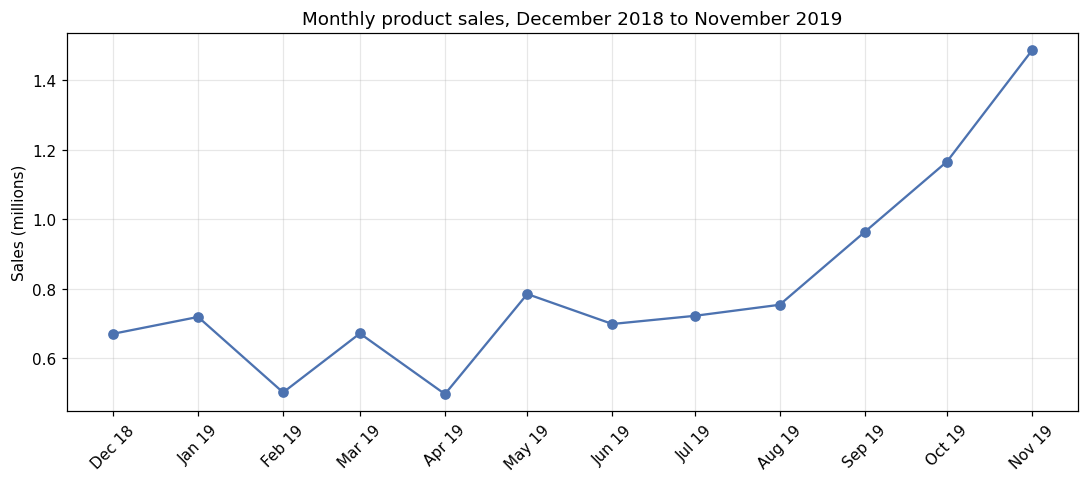

InvoiceDate,2018-12-01,2019-01-01,2019-02-01,2019-03-01,2019-04-01,2019-05-01,2019-06-01,2019-07-01,2019-08-01,2019-09-01,2019-10-01,2019-11-01
Sales (thousands),671.00,719.00,502.00,672.00,497.00,785.00,699.00,722.00,754.00,963.00,"1,165.00","1,485.00"


In [8]:
full_months = sales[(sales['InvoiceDate'] >= '2018-12-01') & (sales['InvoiceDate'] < '2019-12-01')]
monthly = full_months.set_index('InvoiceDate')['Revenue'].resample('MS').sum()

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(monthly.index, monthly / 1e6, marker='o', color='#4c72b0')
ax.set_title('Monthly product sales, December 2018 to November 2019')
ax.set_ylabel('Sales (millions)')
ax.set_xticks(monthly.index)
ax.set_xticklabels(monthly.index.strftime('%b %y'), rotation=45)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('images/monthly_sales.png', bbox_inches='tight')
plt.show()

(monthly / 1e3).round(0).to_frame('Sales (thousands)').T

Sales are fairly stable at 0.5 to 0.8 million a month for most of the year and then climb steeply from September, reaching about 1.5 million in November, more than double the spring months. The store's year is dominated by the run-up to Christmas.

Because the dates in this dataset appear to have been shifted for anonymisation, day-of-week patterns are not interpreted here.

## 4. Product Range Analysis (ABC Analysis)

Product performance is measured by net revenue, which subtracts cancelled quantities from sales. This matters: some products only look like top sellers because of a single huge order that was later cancelled.

In [9]:
product_sales = sales.groupby('StockCode').agg(
    Description=('Description', 'first'), Gross_revenue=('Revenue', 'sum'),
    Quantity=('Quantity', 'sum'), Median_price=('UnitPrice', 'median'))
product_cancels = cancellations.groupby('StockCode').agg(
    Cancelled_revenue=('Revenue', 'sum'), Cancelled_qty=('Quantity', 'sum'))

products = product_sales.join(product_cancels).fillna({'Cancelled_revenue': 0, 'Cancelled_qty': 0})
products['Net_revenue'] = products['Gross_revenue'] + products['Cancelled_revenue']
products['Net_quantity'] = products['Quantity'] + products['Cancelled_qty']

products.sort_values('Gross_revenue', ascending=False).head(6)[['Description', 'Gross_revenue', 'Cancelled_revenue', 'Net_revenue']]

,Description,Gross_revenue,Cancelled_revenue,Net_revenue
StockCode,,,,
22423,REGENCY CAKESTAND 3 TIER,"174,156.54","-9,697.05","164,459.49"
23843,"PAPER CRAFT , LITTLE BIRDIE","168,469.60","-168,469.60",0.00
85123A,WHITE HANGING HEART T-LIGHT HOLDER,"104,462.75","-6,624.30","97,838.45"
47566,PARTY BUNTING,"99,445.23","-1,201.35","98,243.88"
85099B,JUMBO BAG RED RETROSPOT,"94,159.81","-1,984.02","92,175.79"
23166,MEDIUM CERAMIC TOP STORAGE JAR,"81,700.92","-77,479.64","4,221.28"


"PAPER CRAFT, LITTLE BIRDIE" ranks second by gross revenue, but the entire amount comes from one order of 80,995 units that was cancelled in full, so its net revenue is zero. "MEDIUM CERAMIC TOP STORAGE JAR" has a similar story. Ranking by net revenue removes these distortions.

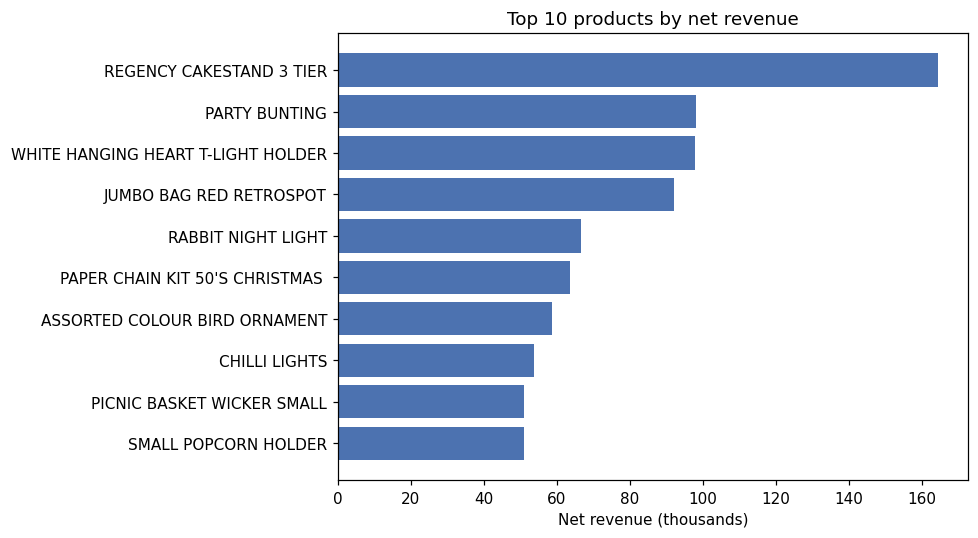

In [10]:
top_net = products.sort_values('Net_revenue', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top_net['Description'][::-1], top_net['Net_revenue'][::-1] / 1e3, color='#4c72b0')
ax.set_title('Top 10 products by net revenue')
ax.set_xlabel('Net revenue (thousands)')
plt.tight_layout()
plt.show()

ABC analysis classifies products by their contribution to revenue. Class A products together generate the first 80% of net revenue, class B the next 15%, and class C the final 5%.

In [11]:
abc = products[products['Net_revenue'] > 0].sort_values('Net_revenue', ascending=False).copy()
abc['Cumulative_share'] = abc['Net_revenue'].cumsum() / abc['Net_revenue'].sum()
abc['Class'] = np.select([abc['Cumulative_share'] <= 0.80, abc['Cumulative_share'] <= 0.95], ['A', 'B'], 'C')

summary = abc.groupby('Class').agg(Products=('Net_revenue', 'size'), Revenue=('Net_revenue', 'sum'))
summary['Share of products (%)'] = summary['Products'] / summary['Products'].sum() * 100
summary['Share of revenue (%)'] = summary['Revenue'] / summary['Revenue'].sum() * 100
summary

,Products,Revenue,Share of products (%),Share of revenue (%)
Class,,,,
A,839,"7,814,766.97",21.52,79.97
B,979,"1,468,186.98",25.11,15.02
C,2081,"488,678.75",53.37,5.00


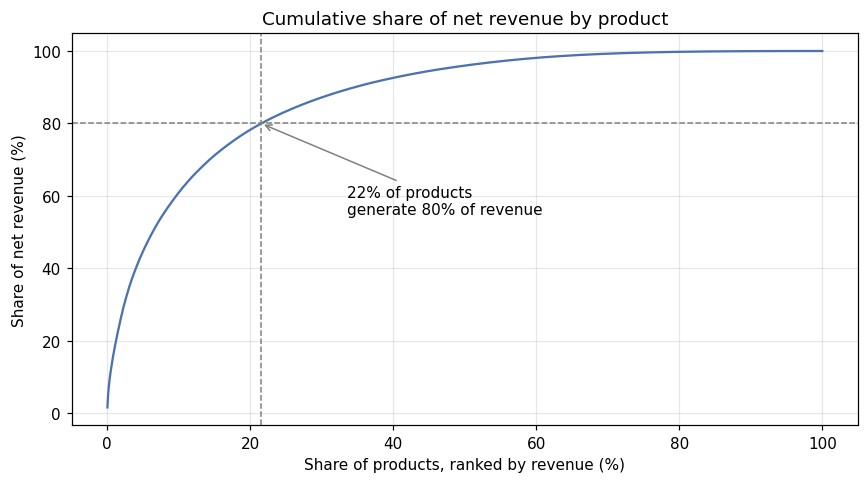

In [12]:
fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(1, len(abc) + 1) / len(abc) * 100
ax.plot(x, abc['Cumulative_share'] * 100, color='#4c72b0')
a_share = summary.loc['A', 'Share of products (%)']
ax.axhline(80, color='grey', ls='--', lw=1)
ax.axvline(a_share, color='grey', ls='--', lw=1)
ax.annotate(f'{a_share:.0f}% of products\ngenerate 80% of revenue', xy=(a_share, 80), xytext=(a_share + 12, 55),
            arrowprops=dict(arrowstyle='->', color='grey'))
ax.set_title('Cumulative share of net revenue by product')
ax.set_xlabel('Share of products, ranked by revenue (%)')
ax.set_ylabel('Share of net revenue (%)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('images/abc_curve.png', bbox_inches='tight')
plt.show()

The range is highly concentrated. About a fifth of products (class A) generate 80% of net revenue, while more than half (class C) together contribute only 5%. Class C products tie up catalogue space, stock and management attention for very little return, which makes them the natural starting point for rationalising the range.

## 5. Seasonal Products

Given the strong pre-Christmas peak, it is worth checking how much of it comes from explicitly seasonal products. Products are flagged as Christmas items if their description contains "CHRISTMAS", "XMAS" or "ADVENT".

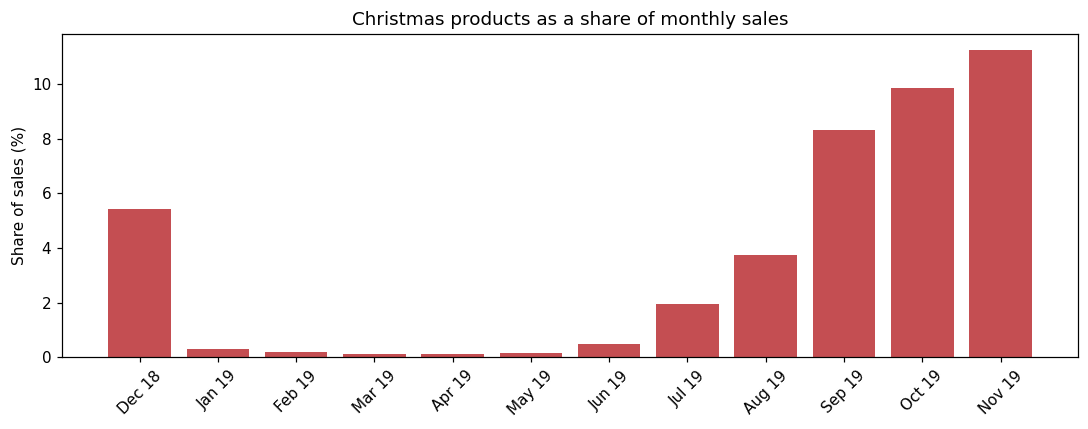

In [13]:
full_months = full_months.copy()
full_months['Christmas_item'] = full_months['Description'].str.contains('CHRISTMAS|XMAS|ADVENT', case=False, na=False)
xmas = full_months.set_index('InvoiceDate').groupby([pd.Grouper(freq='MS'), 'Christmas_item'])['Revenue'].sum().unstack()
xmas_share = xmas[True] / xmas.sum(axis=1) * 100

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(xmas_share.index.strftime('%b %y'), xmas_share, color='#c44e52')
ax.set_title('Christmas products as a share of monthly sales')
ax.set_ylabel('Share of sales (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Christmas products are almost absent from January to June but rise to around 10% of sales between September and November. Even at their peak, though, they account for only a small part of the autumn surge, which shows that customers buy more of the whole range before Christmas, not just seasonal items. This is consistent with retailers stocking up for the holiday season.

## 6. Cancellations and Returns

In [14]:
returns = products[products['Quantity'] >= 500].copy()
returns['Cancelled_share_of_units (%)'] = -returns['Cancelled_qty'] / returns['Quantity'] * 100
returns.sort_values('Cancelled_share_of_units (%)', ascending=False).head(8)[['Description', 'Quantity', 'Cancelled_qty', 'Cancelled_share_of_units (%)']]

,Description,Quantity,Cancelled_qty,Cancelled_share_of_units (%)
StockCode,,,,
23843,"PAPER CRAFT , LITTLE BIRDIE",80995,"-80,995.00",100.00
84347,ROTATING SILVER ANGELS T-LIGHT HLDR,9461,"-9,376.00",99.10
23166,MEDIUM CERAMIC TOP STORAGE JAR,78033,"-74,494.00",95.46
23113,PANTRY CHOPPING BOARD,1154,-946.00,81.98
23055,IVORY CHANDELIER T-LIGHT HOLDER,657,-432.00,65.75
23056,FLOWERS CHANDELIER T-LIGHT HOLDER,963,-579.00,60.12
47566B,TEA TIME PARTY BUNTING,2379,"-1,424.00",59.86
23057,GEMSTONE CHANDELIER T-LIGHT HOLDER,773,-433.00,56.02


Cancellations amount to about 4.6% of gross product sales. Among products with at least 500 units sold, a few stand out with very high cancellation shares, several of them driven by single very large orders that were cancelled. Bulk orders of this size should trigger a confirmation step before fulfilment.

## 7. Customer Analysis (RFM Segmentation)

Customer analysis uses only transactions with a customer ID, which cover about 85% of product sales. Each customer is scored from 1 to 5 on recency (days since the last purchase), frequency (number of orders) and monetary value (total spend), using quintiles.

In [15]:
customers = sales.dropna(subset=['CustomerID'])
snapshot = sales['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = customers.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda d: (snapshot - d.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('Revenue', 'sum'))

rfm['R'] = pd.qcut(rfm['Recency'].rank(method='first'), 5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm['F'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm['M'] = pd.qcut(rfm['Monetary'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5]).astype(int)

def segment(row):
    if row['R'] >= 4 and row['F'] >= 4:
        return 'Champions'
    if row['F'] >= 4:
        return 'Loyal but slipping'
    if row['R'] >= 4 and row['F'] <= 2:
        return 'New or occasional'
    if row['R'] <= 2 and row['F'] >= 3:
        return 'At risk'
    if row['R'] <= 2 and row['F'] <= 2:
        return 'Lost'
    return 'Needs attention'

rfm['Segment'] = rfm.apply(segment, axis=1)
seg = rfm.groupby('Segment').agg(Customers=('Monetary', 'size'), Revenue=('Monetary', 'sum'),
                                 Median_recency=('Recency', 'median'), Median_orders=('Frequency', 'median'))
seg['Share of customers (%)'] = seg['Customers'] / seg['Customers'].sum() * 100
seg['Share of revenue (%)'] = seg['Revenue'] / seg['Revenue'].sum() * 100
seg.sort_values('Revenue', ascending=False)

,Customers,Revenue,Median_recency,Median_orders,Share of customers (%),Share of revenue (%)
Segment,,,,,,
Champions,1120,"5,777,206.02",11.00,7.00,25.84,66.12
Loyal but slipping,614,"1,267,795.36",66.00,4.00,14.17,14.51
Needs attention,840,"713,306.66",40.00,2.00,19.38,8.16
Lost,1078,"515,889.91",219.00,1.00,24.87,5.90
At risk,372,"323,682.04",154.50,2.00,8.58,3.70
New or occasional,310,"139,347.65",19.00,1.00,7.15,1.59


In [16]:
top_decile = rfm['Monetary'].sort_values(ascending=False)
top_share = top_decile.head(len(top_decile) // 10).sum() / top_decile.sum() * 100
print(f"Customers: {len(rfm):,}")
print(f"Share of revenue from the top 10% of customers: {top_share:.1f}%")
print(f"Share of customers with only one order: {(rfm['Frequency'] == 1).mean() * 100:.1f}%")

Customers: 4,334
Share of revenue from the top 10% of customers: 61.4%
Share of customers with only one order: 34.7%


Revenue is concentrated among a small group of customers: the top 10% generate about 61% of revenue, and the Champions segment, customers who buy often and recently, makes up about a quarter of customers but generates two-thirds of revenue. At the same time, about 35% of customers ordered only once. The pattern points to a core of repeat business buyers alongside a large group of one-off shoppers who are not being converted into regular customers.

## 8. Hypothesis Testing

### 8.1 Is price associated with the quantity sold?

The original analysis used an independent t-test to compare the mean of `Quantity` with the mean of `UnitPrice`. That test compares two different variables measured in different units, so it cannot answer the question. The right tool is a correlation between price and quantity across products. Spearman's rank correlation is used because both variables are highly skewed.

H₀: there is no monotonic association between a product's price and the number of units sold.
H₁: there is a monotonic association between a product's price and the number of units sold.

In [17]:
corr_data = products[products['Net_quantity'] > 0]
rho, p = stats.spearmanr(corr_data['Median_price'], corr_data['Net_quantity'])
print(f"Spearman's rho = {rho:.3f}, p-value = {p:.2e}, products = {len(corr_data):,}")

Spearman's rho = -0.378, p-value = 2.41e-132, products = 3,896


The p-value is far below 0.05, so the null hypothesis is rejected: cheaper products sell in substantially larger quantities, with a moderate negative correlation. This is a comparison across different products, so it does not show that cutting the price of any given product would raise its sales; it describes the shape of the range, in which low-priced items move in volume.

### 8.2 Does the quantity sold differ between seasons?

The original analysis compared only two pairs of seasons using individual transaction rows, which include extreme values. Here, total units sold per trading day over the twelve full months are compared across all four seasons at once with the Kruskal–Wallis test, a non-parametric test suitable for skewed data.

H₀: daily units sold have the same distribution in all four seasons.
H₁: daily units sold differ in at least one season.

In [18]:
season_map = {12: 'Winter', 1: 'Winter', 2: 'Winter', 3: 'Spring', 4: 'Spring', 5: 'Spring',
              6: 'Summer', 7: 'Summer', 8: 'Summer', 9: 'Autumn', 10: 'Autumn', 11: 'Autumn'}
daily_units = full_months.set_index('InvoiceDate')['Quantity'].resample('D').sum()
daily_units = daily_units[daily_units > 0].to_frame('Units')
daily_units['Season'] = daily_units.index.month.map(season_map)

groups = [g['Units'].values for _, g in daily_units.groupby('Season')]
h, p = stats.kruskal(*groups)
print(daily_units.groupby('Season')['Units'].agg(['count', 'median']).round(0))
print(f"\nKruskal-Wallis H = {h:.1f}, p-value = {p:.2e}")

        count    median
Season                 
Autumn     78 25,366.00
Spring     73 14,523.00
Summer     78 14,628.00
Winter     68 13,102.00

Kruskal-Wallis H = 72.5, p-value = 1.27e-15


The null hypothesis is rejected. On a typical trading day in autumn, the store sells about 25,000 units, compared with roughly 13,000 to 15,000 in the other seasons, confirming that autumn is the decisive season for the business.

## 9. Conclusions and Recommendations

After cleaning, the store generated about 10.2 million in product sales over the period, or 9.8 million after cancellations, from roughly 3,900 products and 4,300 identified customers. Several figures in the original analysis were distorted by uncleaned data: postage appeared as the top-earning "product", a fully cancelled order inflated the product rankings, and a seemingly significant drop in December sales was caused by the data ending on 7 December.

The product range is highly concentrated. About a fifth of products generate 80% of net revenue, while more than half contribute only 5%. Demand is strongly seasonal: sales double between spring and November, and the autumn surge covers the whole range rather than only Christmas items. Lower-priced products sell in much higher volumes. Revenue also depends heavily on a small number of customers, with the top 10% generating about 61% of revenue, many of them apparently business buyers, while about a third of customers never return after their first order.

The store should protect availability of its class A products, especially ahead of the September to November peak, and plan stock and staffing for that period well in advance. Class C products should be reviewed for discontinuation or bundling, which would free up capital and simplify operations. A dedicated programme for the high-value repeat buyers, such as volume pricing or account management, would protect the revenue base, while a follow-up offer after the first order could convert more one-time shoppers into repeat customers. Finally, unusually large orders should require confirmation before fulfilment to reduce costly cancellations.